# ITER Flattop — TokaMaker_TORAX

Simulates the ITER H-mode flattop at 15 MA using TokaMaker_TORAX.

Initial conditions (profiles, equilibrium shape) are taken from the **start** of
`iter_rampdown_fitzpatrick2026_sim2_v1.py`, which itself begins at full flattop.
The `fly()` call uses `steady_state_mode=True` (following `ARC_flattop.py`) to
relax the coupled MHD + kinetics to a self-consistent flattop state.

**Key references:**
- Device / mesh: `ITER_mesh.h5`
- Shape / initial profiles: `iter_rampdown_fitzpatrick2026_sim2_v1.py` (flat_start seed)
- Steady-state coupling pattern: `ARC_flattop.py`

## 1. Imports and environment setup

In [1]:
import os
import shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['lines.linewidth'] = 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.pulse_design import TokaMaker_TORAX
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_power_flux_fun
from omfit_classes.utils_fusion import Hmode_profiles

# Clear jax_cache to avoid semaphore leaks between runs
_jax_cache = Path('/Users/fsheehan/jax_cache')
if _jax_cache.exists():
    for item in _jax_cache.iterdir():
        shutil.rmtree(item) if item.is_dir() else item.unlink()

## 2. Device parameters and simulation timing

All values are taken from the full-scale ITER configuration used in
`iter_rampdown_fitzpatrick2026_sim2_v1.py`.

| Parameter | Value | Note |
|-----------|-------|------|
| R0 | 6.2 m | Major radius |
| B0 | 5.3 T | On-axis toroidal field |
| Ip | 15 MA | Full ITER design current |
| κ | 1.7 | Design elongation |
| δ | 0.4 | Design triangularity |

In [ ]:
NOTEBOOK_DIR = Path('.').resolve()
MESH_H5 = NOTEBOOK_DIR / 'ITER_mesh.h5'

# Device
R0      = 6.2    # m, major radius
B0      = 5.3    # T, on-axis toroidal field
Z0      = 0.5    # m, vertical centering on TokaMaker grid
A_FLAT  = 2.0    # m, minor radius
KAPPA   = 1.7    # elongation
DELTA   = 0.4    # triangularity

IP_FLAT = 15.0e6  # A

# Simulation window — long enough to reach steady state
T_FINAL     = 400.0  # s

# Pedestal / density reference
NE_FLAT    = 1.0e20   # m^-3
ZEFF       = 1.7

print(f'ITER flattop: Ip={IP_FLAT/1e6:.1f} MA,  R0={R0} m,  B0={B0} T')
print(f'Simulation:   t=[{0}, {T_FINAL}] s')

ITER flattop: Ip=15.0 MA,  R0=6.2 m,  B0=5.3 T
Simulation:   t=[0.0, 400.0] s


## 3. ITER lower single-null geometry

The X-point location and isoflux boundary points are identical to those used in
the rampdown script's `flat_start` seed — a lower single-null (LSN) diverted
configuration.

The 11-point isoflux set was chosen to force the LCFS to wrap around the lower
X-point rather than allowing the GS solver to find a spurious upper saddle.

In [3]:
# Lower single-null X-point
X_POINTS = np.array([[5.125, -3.4]])

# Fixed asymmetric LCFS isoflux points (LSN, from rampdown flat_start seed)
DIVERTED_ISOFLUX_PTS = np.array([
    [8.20,  0.41],
    [8.06,  1.46],
    [7.51,  2.62],
    [6.14,  3.78],
    [5.10,  3.72],
    [4.51,  3.02],
    [4.26,  1.33],
    [4.28,  0.08],
    [4.49, -1.34],
    [7.28, -1.89],
    [8.00, -0.68],
])

## 4. TokaMaker setup

Initialise the Grad-Shafranov solver with the ITER mesh. The vertical stability
coil (`VS`) and coil bounds are configured identically to the rampdown script.

In [4]:
myOFT = OFT_env(nthreads=4)
mygs  = TokaMaker(myOFT)

mesh_pts, mesh_lc, mesh_reg, coil_dict, cond_dict = load_gs_mesh(str(MESH_H5))
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict, coil_dict=coil_dict)
mygs.settings.maxits = 300
mygs.setup(order=2, F0=R0 * B0)

mygs.set_coil_vsc({'VS': 1.0})

coil_bounds = {key: [-50.0e6, 50.0e6] for key in mygs.coil_sets}
mygs.set_coil_bounds(coil_bounds)

#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:    tmtx_updates_1
Revision id:           36fc532
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    4
Integer Precisions    =    4   8
Float Precisions      =    4   8  16
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  2.859E+02
    # of points  =    4757
    # of edges   =   14156
    # of cells   =    9400
    # of boundary points =     112
    # of boundary edges  =     112
    # of boundary cells  =     112
  Resolution statistics:
    hmin =  9.924E-03
    hrms =  2.826E-01
    hmax =  8.466E-01
  Surface grounded at vertex     870


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Tim

### 4.1 Coil regularization

Min-norm regularization penalises coil current amplitude while a high-weight
term on `#VSC` prevents the virtual VSC from interfering with the real `VS` coil.

In [5]:
def build_min_norm_coil_reg(mygs):
    reg_terms = []
    for name in mygs.coil_sets:
        if name.startswith('CS'):
            w = 2.0e-2 if name.startswith('CS1') else 1.0e-2
            reg_terms.append(mygs.coil_reg_term({name: 1.0}, target=0.0, weight=w))
        elif name.startswith('PF'):
            reg_terms.append(mygs.coil_reg_term({name: 1.0}, target=0.0, weight=1.0e-2))
        elif name.startswith('VS'):
            reg_terms.append(mygs.coil_reg_term({name: 1.0}, target=0.0, weight=1.0e-2))
    reg_terms.append(mygs.coil_reg_term({'#VSC': 1.0}, target=0.0, weight=1.0e2))
    mygs.set_coil_reg(reg_terms=reg_terms)

build_min_norm_coil_reg(mygs)

## 5. Initial equilibrium

Solve a single inverse equilibrium at full ITER flattop conditions.
The H-mode current/pressure profile shapes `(α, γ) = (1.5, 2.0)` for FF' and
`(2.0, 1.5)` for P' are the same as in the rampdown script.

In [6]:
# H-mode-like profile shapes
ffp_prof = create_power_flux_fun(40, 1.5, 2.0)
pp_prof  = create_power_flux_fun(40, 2.0, 1.5)
mygs.set_profiles(ffp_prof=ffp_prof, pp_prof=pp_prof)

# Peak pressure at flattop: 2 * ne * Te_core
TE_CORE_KEV = 20.0
pax_flat = 2.0 * NE_FLAT * TE_CORE_KEV * 1e3 * 1.602e-19
print(f'Target pax = {pax_flat/1e3:.1f} kPa')

Target pax = 640.8 kPa


In [7]:
# Set shape constraints (LSN diverted)
mygs.set_saddle_constraints(X_POINTS)
mygs.set_isoflux_constraints(DIVERTED_ISOFLUX_PTS)

isoflux_weights = np.full(DIVERTED_ISOFLUX_PTS.shape[0], 10.0)
isoflux_targets = np.zeros(DIVERTED_ISOFLUX_PTS.shape[0])
mygs.set_psi_constraints(DIVERTED_ISOFLUX_PTS, isoflux_targets, weights=isoflux_weights)

build_min_norm_coil_reg(mygs)
mygs.set_targets(Ip=IP_FLAT, pax=pax_flat)
mygs.init_psi(R0, Z0, A_FLAT, KAPPA, DELTA)
mygs.solve()
mygs.print_info()

Starting non-linear GS solver
     1  8.2251E+00  1.7033E-01  6.0508E-01  6.4217E+00  5.3467E-01 -2.2681E-05
     2  1.6251E+01  1.1444E-01  2.4854E-01  6.4017E+00  5.3975E-01 -3.9783E-05
     3  1.9147E+01  1.0106E-01  1.2064E-01  6.3883E+00  5.4344E-01  3.1314E-05
     4  2.0602E+01  9.6166E-02  7.3133E-02  6.3807E+00  5.4577E-01  1.1092E-04
     5  2.1429E+01  9.3894E-02  4.7468E-02  6.3763E+00  5.4719E-01  1.7559E-04
     6  2.1921E+01  9.2685E-02  3.0759E-02  6.3738E+00  5.4800E-01  2.2146E-04
     7  2.2220E+01  9.1992E-02  1.9663E-02  6.3724E+00  5.4844E-01  2.5199E-04
     8  2.2402E+01  9.1582E-02  1.2439E-02  6.3715E+00  5.4866E-01  2.7174E-04
     9  2.2514E+01  9.1334E-02  7.8043E-03  6.3710E+00  5.4876E-01  2.8426E-04
    10  2.2583E+01  9.1184E-02  4.8813E-03  6.3707E+00  5.4880E-01  2.9209E-04
    11  2.2625E+01  9.1092E-02  3.0455E-03  6.3705E+00  5.4880E-01  2.9697E-04
    12  2.2651E+01  9.1036E-02  1.8977E-03  6.3704E+00  5.4878E-01  2.9999E-04
    13  2.2666E+01  9.

    26  2.2691E+01  9.0947E-02  2.8551E-06  6.3703E+00  5.4868E-01  3.0487E-04
    27  2.2691E+01  9.0947E-02  1.8254E-06  6.3703E+00  5.4868E-01  3.0487E-04
    28  2.2691E+01  9.0947E-02  1.1704E-06  6.3703E+00  5.4868E-01  3.0487E-04
    29  2.2691E+01  9.0947E-02  7.5265E-07  6.3703E+00  5.4868E-01  3.0487E-04
 Timing:  0.18742899992503226     
   Source:     5.8775999350473285E-002
   Solve:      4.7887000720947981E-002
   Boundary:   7.0860006380826235E-003
   Other:      7.3679999215528369E-002
Equilibrium Statistics:
  Topology                =   Diverted
  Toroidal Current [A]    =    1.5000E+07
  Current Centroid [m]    =    6.210  0.554
  Magnetic Axis [m]       =    6.370  0.549
  Elongation              =    1.860 (U:  1.748, L:  1.973)
  Triangularity           =    0.435 (U:  0.349, L:  0.521)
  Plasma Volume [m^3]     =   851.969
  q_0, q_95               =    0.778  2.957
  Plasma Pressure [Pa]    =   Axis:  6.3971E+05, Peak:  6.3971E+05
  Stored Energy [J]       =    

Saving gEQDSK: /Users/fsheehan/github/TokaMaker_TORAX_project/ITER_flattop_seed.eqdsk
 Using COCOS=2...
Saved: ITER_flattop_seed.eqdsk


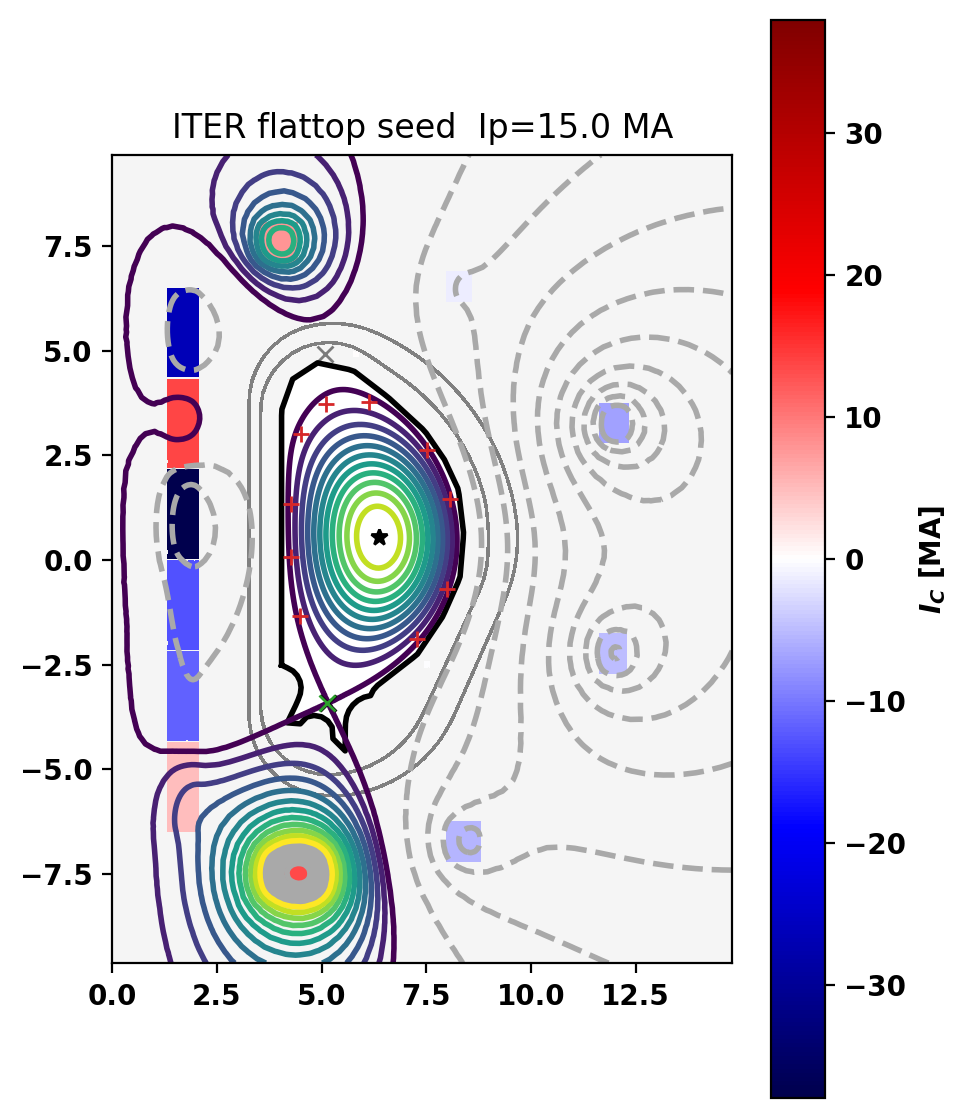

In [8]:
# Save eqdsk and plot
eqdsk_path = NOTEBOOK_DIR / 'ITER_flattop_seed.eqdsk'
mygs.save_eqdsk(str(eqdsk_path), cocos=2, nr=750, nz=750)
print(f'Saved: {eqdsk_path.name}')

fig, ax = plt.subplots(1, 1, figsize=(5, 7))
mygs.plot_machine(fig, ax, coil_colormap='seismic', coil_scale=1.0e-6,
                  coil_clabel=r'$I_C$ [MA]', coil_symmap=True)
mygs.plot_psi(fig, ax, plasma_nlevels=12, vacuum_nlevels=10)
mygs.plot_constraints(fig, ax)
ax.set_title(f'ITER flattop seed  Ip={IP_FLAT/1e6:.1f} MA')
fig.savefig(NOTEBOOK_DIR / 'ITER_flattop_seed_eqdsk.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. TokaMaker_TORAX coupling

Because the equilibrium is held fixed at flattop, both `eqtimes` and
`g_eqdsk_arr` reference the single seed eqdsk at the start and end of the
simulation window.

In [ ]:
tm_times = np.linspace(0, T_FINAL, 3)

tmtx = TokaMaker_TORAX(
    t_init=0,
    t_final=T_FINAL,
    tx_dt=0.5,
    eqtimes=np.array([0, T_FINAL]),
    g_eqdsk_arr=[str(eqdsk_path), str(eqdsk_path)],
    last_surface_factor=0.9999,
    tm_times=tm_times,
    tokamaker_obj=mygs,
)

## 7. TORAX configuration

Transport smoothing and geometry settings follow the ARC flattop pattern.
Sawteeth are enabled (as in the rampdown script) since the ITER q-profile
is expected to be sawtoothing during flattop.

In [10]:
loaded_config = {
    'transport': {
        'smooth_everywhere': True,
        'smoothing_width': 0.10,
    },
    'mhd': {
        'sawtooth': {
            'trigger_model': {'model_name': 'simple'},
            'redistribution_model': {'model_name': 'simple'},
        },
    },
    'geometry': {
        'n_surfaces': 51,
    },
    'solver': {
        'n_corrector_steps': 3,
    },
}

tmtx.load_TORAX_config(loaded_config)
tmtx.set_TORAX_grid(grid_type='n_rho', grid=51)

## 8. Heating and fueling

ITER flattop heating is primarily alpha-heated, supplemented by modest ECRH and
NBI. Values are taken from the rampdown script's flat-start heating schedule:

| Source | Power | Location (ρ) |
|--------|-------|-------------|
| ECRH   | 3 MW  | 0.4 (off-axis) |
| NBI    | 5 MW  | 0.5 (off-axis) |

In [ ]:
P_ECRH = 3.0e6   # W
P_NBI  = 5.0e6   # W

tmtx.set_heating(
    generic_heat={0: P_NBI},
    generic_heat_loc=0.50,    # off-axis NBI to flatten current profile
    nbi_current=True,
    ecrh={0: P_ECRH},
    ecrh_loc=0.40,            # off-axis ECRH to lift q0
)

# Fueling: moderate gas puff + deep pellets to sustain H-mode density
tmtx.set_fueling(
    gas_puff_S_total={0: 1.0e20},
    gas_puff_decay_length=0.10,
    pellet_S_total={0: 8.0e19},
    pellet_deposition_location=0.2,
    pellet_width=0.20,
)

## 9. Initial kinetic profiles

H-mode profiles from the rampdown script's flat_start seed.  These are the
starting profiles that will relax to self-consistency during the fly loop.

| Quantity | Axis | Pedestal top | Edge |
|----------|------|--------------|------|
| ne | 1.1×10²⁰ m⁻³ | 7×10¹⁹ m⁻³ | 3×10¹⁹ m⁻³ |
| Te | 20 keV | 4.5 keV | 0.30 keV |
| Ti | 20 keV | 4.5 keV | 0.30 keV |

In [ ]:
n_sample      = 100
psi_sample    = np.linspace(0.0, 1.0, n_sample)

NE_AX        = NE_FLAT * 1.10   # m^-3, slightly peaked core
NE_PED       = 7.0e19            # m^-3, H-mode pedestal top
NE_EDGE      = 3.0e19            # m^-3, separatrix
TE_AX_KEV    = TE_CORE_KEV       # keV
TE_PED_KEV   = 4.5               # keV
TE_EDGE_KEV  = 0.30              # keV

PED_WIDTH    = 0.05              # in rho_pol
PED_TOP_RHO  = 1.0 - PED_WIDTH / 2.0

ne_init = Hmode_profiles(
    edge=NE_EDGE, ped=NE_PED, core=NE_AX, rgrid=n_sample,
    expin=1.2, expout=1.8, widthp=PED_WIDTH, xphalf=PED_TOP_RHO,
)
Te_init = Hmode_profiles(
    edge=TE_EDGE_KEV, ped=TE_PED_KEV, core=TE_AX_KEV, rgrid=n_sample,
    expin=1.5, expout=2.0, widthp=PED_WIDTH, xphalf=PED_TOP_RHO,
)

def array_to_profile_dict(arr, grid):
    return {float(p): float(v) for p, v in zip(grid, arr)}

t0 = float(0)
ne_prof = {t0: array_to_profile_dict(ne_init, psi_sample)}
Te_prof = {t0: array_to_profile_dict(Te_init, psi_sample)}

tmtx.set_ne(ne_prof, right_bc=NE_EDGE)
tmtx.set_Te(Te_prof, right_bc=TE_EDGE_KEV)
tmtx.set_Ti(Te_prof, right_bc=TE_EDGE_KEV)  # Ti = Te at t=0

## 10. Pedestal model

ITER H-mode pedestal targets. Uses `ADAPTIVE_SOURCE` mode with the
Martin scaling formation model — the same approach as both the rampdown
and ARC flattop scripts.

In [ ]:
pedestal_config = {
    'set_pedestal': True,
    'model_name': 'set_T_ped_n_ped',
    'mode': 'ADAPTIVE_SOURCE',
    'use_formation_model_with_adaptive_source': True,

    'pedestal_top_smoothing_width': 0.02,

    'rho_norm_ped_top': 0.93,
    'T_i_ped': 4.5,     # keV
    'T_e_ped': 4.5,     # keV
    'n_e_ped_is_fGW': False,
    'n_e_ped': 7.0e19,  # m^-3

    'formation_model': {
        'model_name': 'martin_scaling',
    },
    'saturation_model': {},
}

tmtx.load_pedestal_config(pedestal_config)

## 11. Plasma setup: Ip waveform, composition, evolved variables, X-point

In [ ]:
tmtx._tm = mygs
tmtx.set_TokaMaker_coil_reg(coil_bounds=coil_bounds, updownsym=False)

# Constant Ip throughout flattop
tmtx.set_Ip({0: IP_FLAT})

# Plasma composition — D-T with Ne impurity (realistic ITER Zeff)
tmtx.set_plasma_composition(
    main_ion={'D': 0.50, 'T': 0.50},
    impurity='Ne',
    Zeff=ZEFF,
)

# Evolve all channels
tmtx.set_evolve(density=True, Ti=True, Te=True, current=True)

# Diverted throughout
tmtx.set_x_points(
    diverted_times=(0, T_FINAL),
    x_point_targets=X_POINTS,
    x_point_weight=100,
)

## 12. Run

`steady_state_mode=True` loops the TORAX-TokaMaker cycle until the kinetic
profiles and equilibrium converge, rather than stepping through time.
This is the same approach used in `ARC_flattop.py` for the ARC flattop case.

Time-averaging (`t_ave_toggle='on'`) is enabled so that sawtooth crashes
do not propagate full amplitude into TokaMaker.

In [ ]:
tmtx.fly(
    run_name='ITER_flattop',
    max_loop=2,
    output_mode=False,
    t_ave_toggle='on',
    t_ave_window=10.0,
    t_ave_causal=False,
    # t_ave_ignore_start=0.25,
    initial_relax=True,
    relax_dt=1.0,
    steady_state_mode=True,
)

  Log file: /Users/fsheehan/github/TokaMaker_TORAX_project/TokaMaker_TORAX_outputs/ITER_flattop_2026-06-02_154349/TokaMaker_TORAX_log_ITER_flattop_2026-06-02_154349.log

 TokaMaker_TORAX  
 run_name = ITER_flattop | t=[0.0, 400.0] s | 10 timepoints | dt=0.5 s | max_loop=3

  Initial TORAX relax
  Initial relax: relax_kinetics ON (evolve_* from set_evolve / config)


Simulating (t=10.00000): 100%|██████████| 100/100 [00:11<00:00,  8.89it/s]



  Loop 1
  TORAX: running simulation...


Simulating (t=400.00000): 100%|██████████| 100/100 [00:31<00:00,  3.14it/s]


  TORAX: done (cflux=25.2940 Wb)
  TokaMaker: solving 10 equilibria...


...

Starting non-linear GS solver
     1 -1.2872E+01 -7.8178E-06  2.9277E-01  6.3768E+00  5.4197E-01  1.4279E-08
     2 -1.2760E+01 -7.8466E-06  6.1962E-02  6.3751E+00  5.4208E-01 -3.3730E-07
     3 -1.2708E+01 -7.8665E-06  1.3628E-02  6.3747E+00  5.4215E-01 -4.2346E-07
     4 -1.2682E+01 -7.8758E-06  4.3359E-03  6.3746E+00  5.4220E-01 -4.7058E-07
     5 -1.2669E+01 -7.8812E-06  2.3469E-03  6.3746E+00  5.4224E-01 -5.2433E-07
     6 -1.2665E+01 -7.8843E-06  2.0858E-03  6.3746E+00  5.4226E-01 -3.5113E-07
     7 -1.2663E+01 -7.8849E-06  3.8551E-03  6.3746E+00  5.4228E-01 -5.0304E-07
     8 -1.2663E+01 -7.8854E-06  2.0274E-03  6.3746E+00  5.4229E-01 -5.5238E-07
     9 -1.2664E+01 -7.8853E-06  4.3473E-04  6.3746E+00  5.4230E-01 -5.5041E-07
    10 -1.2664E+01 -7.8852E-06  1.0773E-04  6.3746E+00  5.4231E-01 -5.5017E-07
    11 -1.2664E+01 -7.8851E-06  2.9873E-05  6.3746E+00  5.4231E-01 -5.5015E-07
    12 -1.2664E+01 -7.8851E-06  8.9282E-06  6.3746E+00  5.4232E-01 -5.5016E-07
    13 -1.2664E+01 -7.

  TM loop 3:  90%|█████████ | 9/10 [00:25<00:02,  2.84s/solve], t=355.56s OK(L0)WARNING: Candidate X-point converged to the existing O-point location   5.90E+00  4.98E+00   5.89E+00  4.98E+00


Starting non-linear GS solver
     1 -1.2790E+01 -7.8445E-06  3.1190E-01  6.3798E+00  5.4183E-01  9.7749E-08
     2 -1.2695E+01 -7.8555E-06  7.5885E-02  6.3807E+00  5.4186E-01 -7.1135E-07
     3 -1.2653E+01 -7.8758E-06  1.2399E-02  6.3810E+00  5.4190E-01 -6.4317E-07
     4 -1.2635E+01 -7.8836E-06  6.3360E-03  6.3812E+00  5.4192E-01 -4.1947E-07
     5 -1.2627E+01 -7.8865E-06  1.3639E-03  6.3812E+00  5.4194E-01 -4.4559E-07
     6 -1.2623E+01 -7.8883E-06  5.4911E-04  6.3813E+00  5.4194E-01 -4.5136E-07
     7 -1.2621E+01 -7.8891E-06  3.2179E-04  6.3813E+00  5.4195E-01 -4.5307E-07
     8 -1.2621E+01 -7.8895E-06  1.0294E-03  6.3813E+00  5.4195E-01 -4.4608E-07
     9 -1.2621E+01 -7.8898E-06  2.9417E-04  6.3813E+00  5.4195E-01 -4.4360E-07
    10 -1.2621E+01 -7.8898E-06  8.3946E-05  6.3813E+00  5.4195E-01 -4.4309E-07
    11 -1.2621E+01 -7.8898E-06  2.6958E-05  6.3813E+00  5.4195E-01 -4.4290E-07
    12 -1.2621E+01 -7.8898E-06  9.9317E-06  6.3813E+00  5.4195E-01 -4.4281E-07
    13 -1.2621E+01 -7.

  TM loop 3: 100%|██████████| 10/10 [00:28<00:00,  2.81s/solve], t=400.00s OK(L0)


  TokaMaker: 10/10 solved (cflux=29.8775 Wb)
	TM summary: 10/10 solved. Levels: raw tx profs: 10.
  Loop 3 result: conv_err=4.609% | TX-TM diff=0.0656% | cflux_TX=29.8579 Wb | cflux_TM=29.8775 Wb
  Loop 3 wall time: 0m 49.3s

  Max loop index (3) reached (err=4.609%)

  Loop   cflux TX [Wb]    cflux TM [Wb]    TX-TM diff %  
  ----------------------------------------------------
  1      25.2940          25.7208          1.6596        
  2      28.5424          29.3183          2.6466        
  3      29.8579          29.8775          0.0656        
  Total sim time: 3m 17.2s
  Outputs saved to: ./TokaMaker_TORAX_outputs/ITER_flattop_2026-06-02_154349
  Log file: /Users/fsheehan/github/TokaMaker_TORAX_project/TokaMaker_TORAX_outputs/ITER_flattop_2026-06-02_154349/TokaMaker_TORAX_log_ITER_flattop_2026-06-02_154349.log


## 13. Post-run summary


  TokaMaker_TORAX Physics Summary
  Q_max                           41.18
  Q_max_time                      313.7
  Q_flattop_avg                   40.37
  E_fusion_total_MJ               1.45e+05
  beta_N_max                      1.491
  H98_max                         1.01
  H98_flattop_avg                 0.9826
  T_e_core_max_keV                23.1
  T_i_core_max_keV                18.03
  n_e_line_avg_max                8.881e+19
  f_GW_max                        0.7514
  q95_min                         3.26
  q0_min                          0.8948
  flux_consumed_Wb                29.88
  P_fusion_max_MW                 369.6
  P_ohmic_max_MW                  1.01
  l_i_flattop_avg                 0.7034
  vloop_tx_flattop_avg_V          0.07391



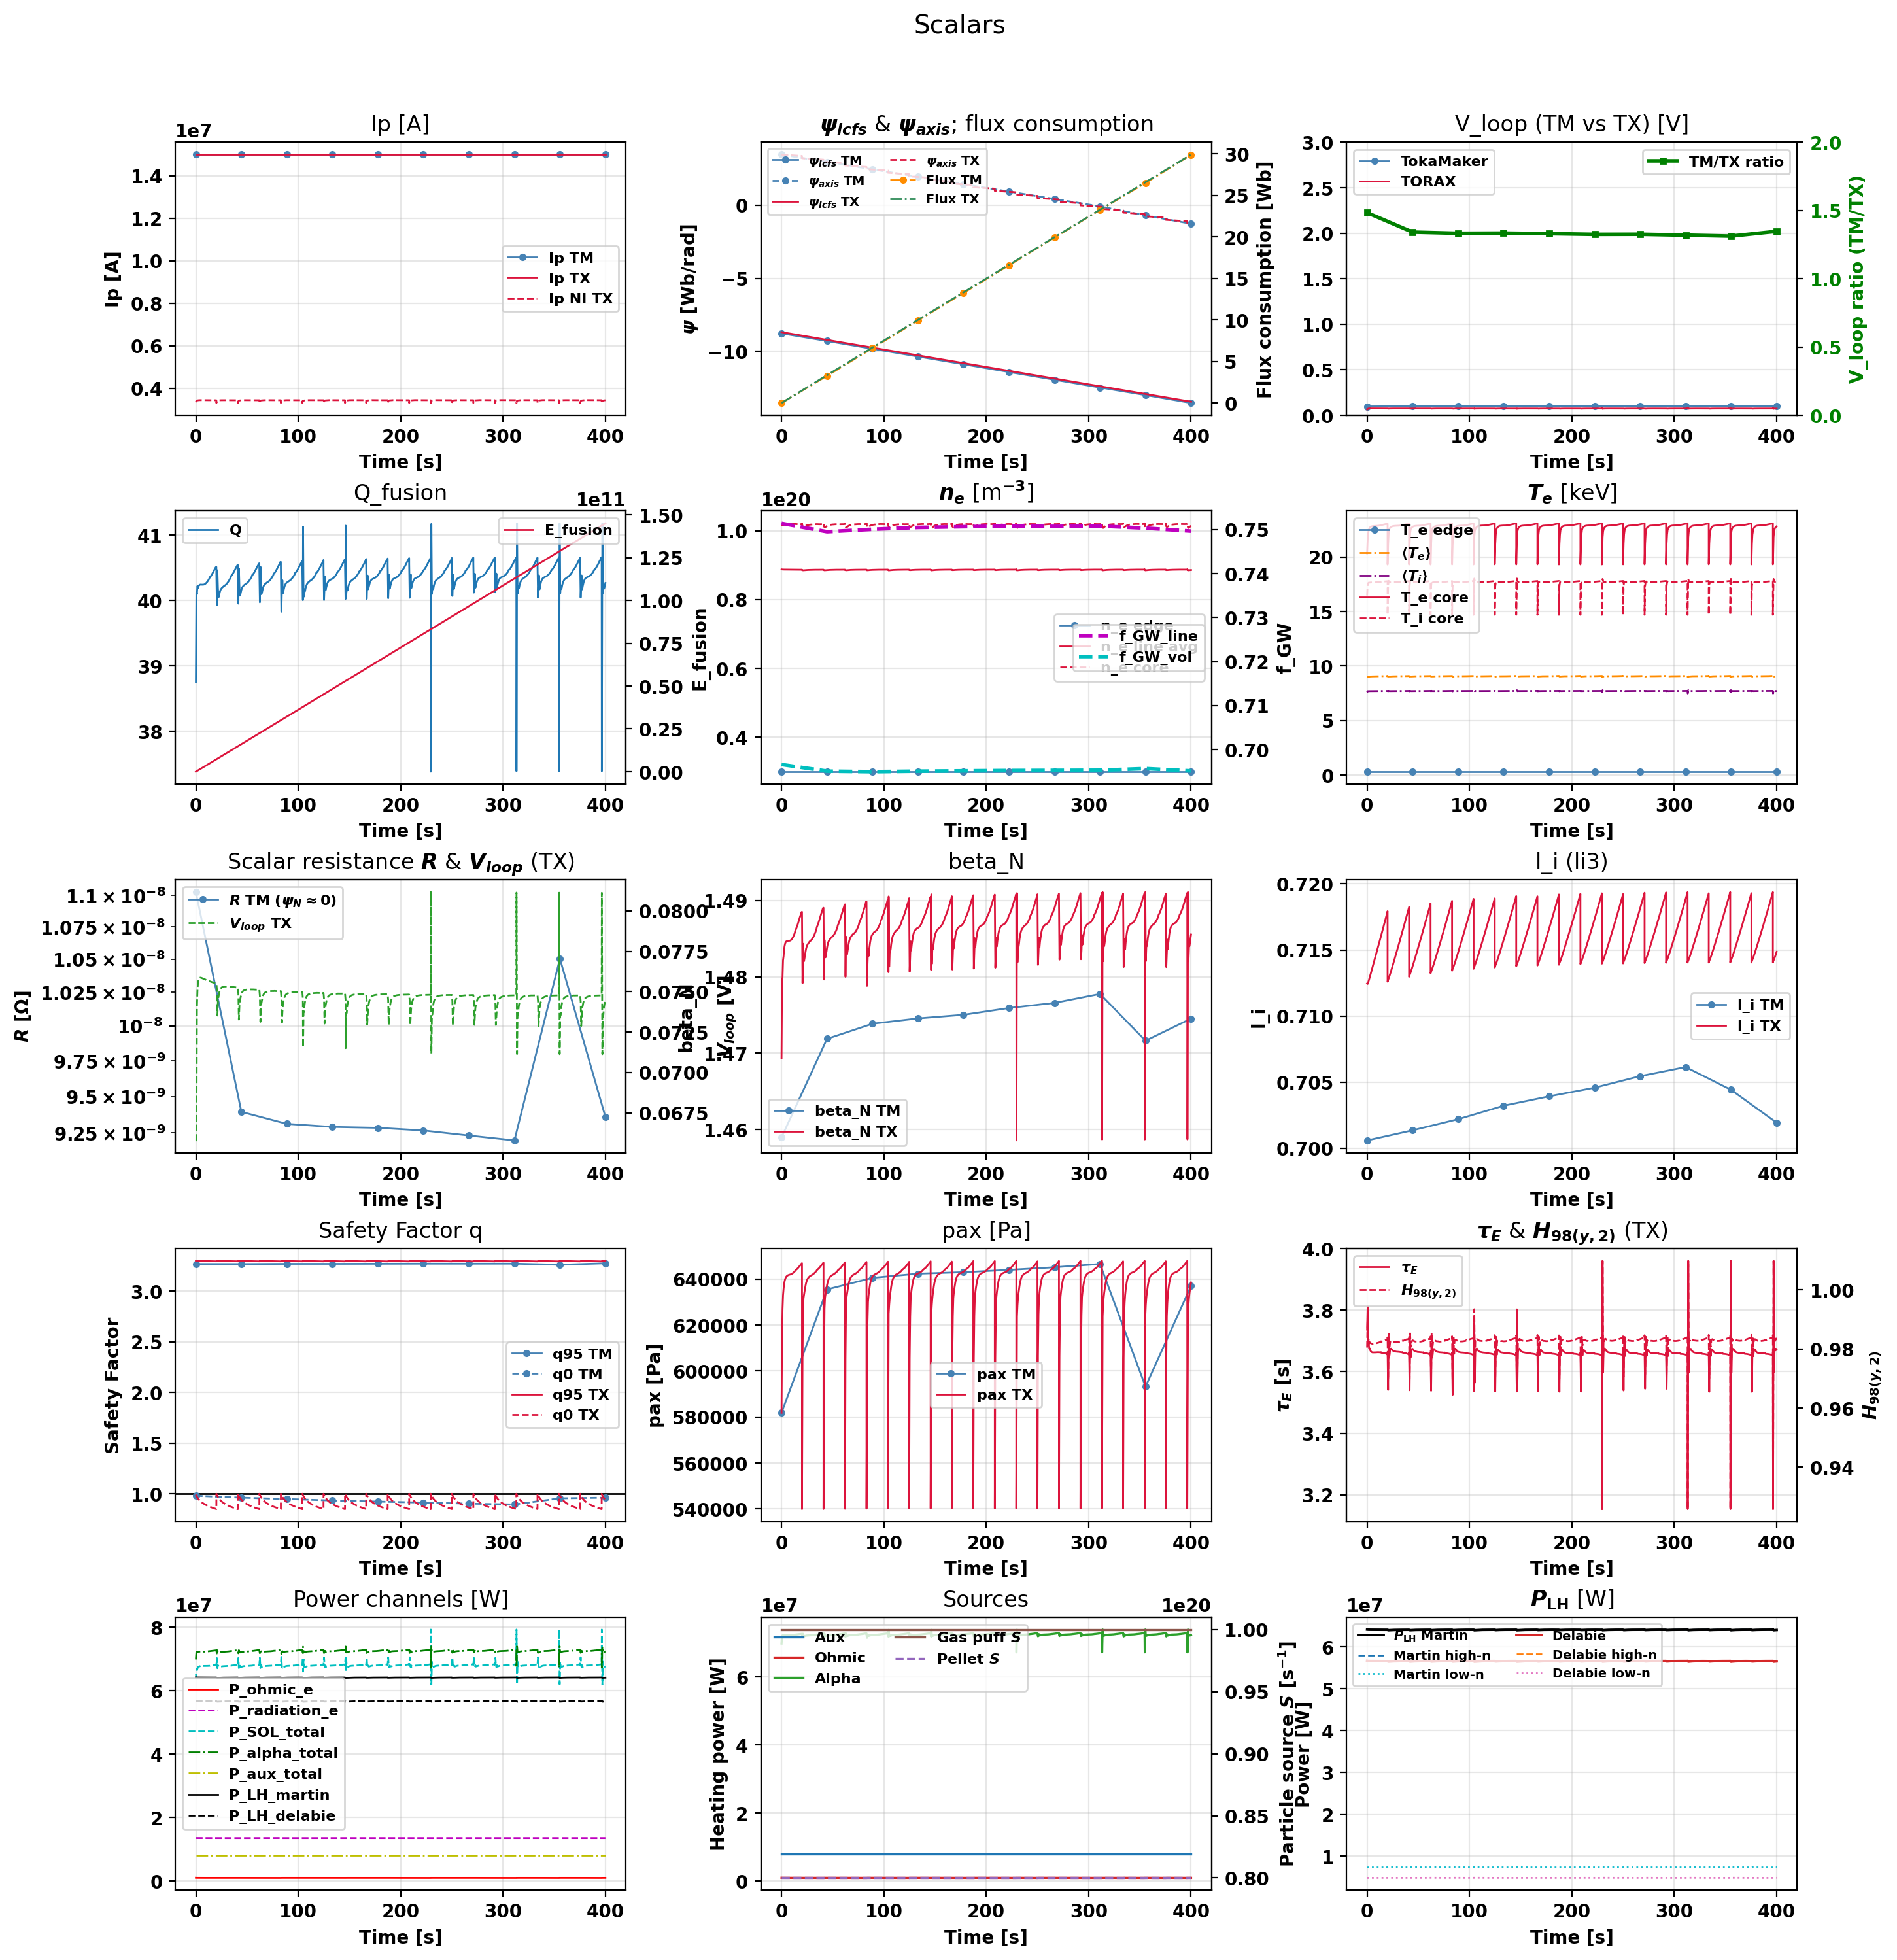

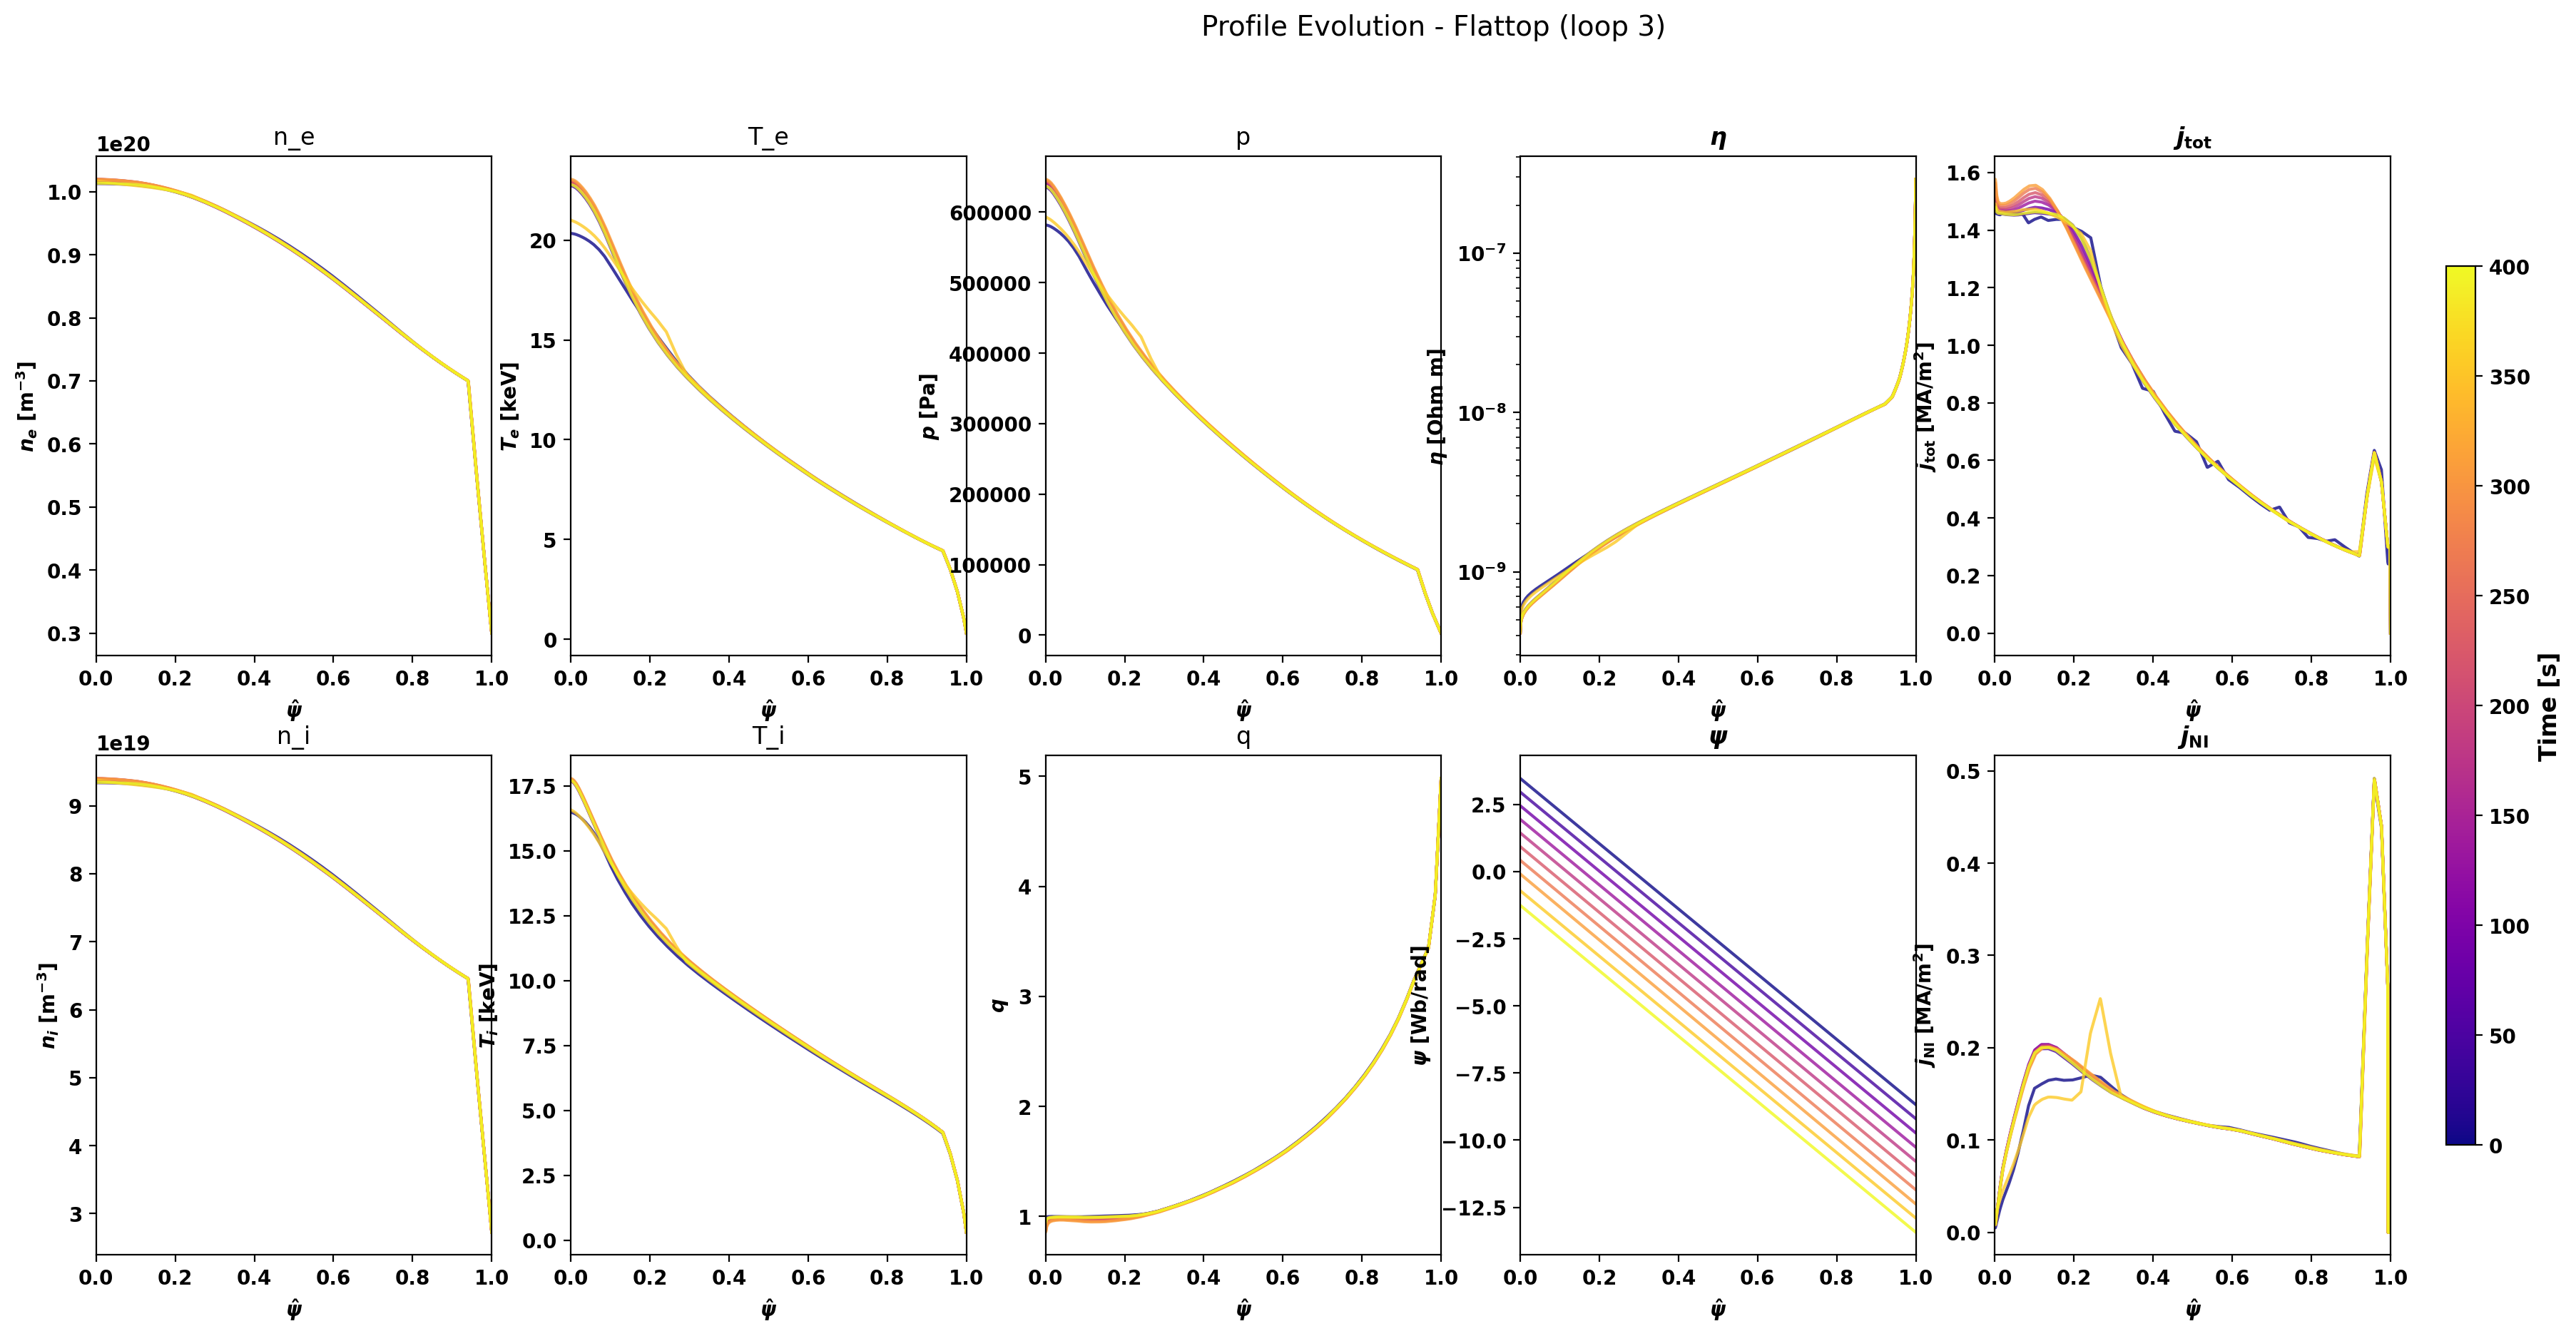

In [ ]:
tmtx.summary()
tmtx.plot_scalars()
tmtx.plot_profile_evolution()
tmtx.make_movie(notebook_mode=True, speed_factor=10)